In [2]:
from datetime import datetime, timezone, timedelta
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

import orbit as om
from constants import mu

R_EARTH_M = 6_378_136.3

print("mu =", mu, "m^3/s^2")


mu = 398601877170000.0 m^3/s^2


## Helper functions

In [35]:
def make_config(
    x0,
    duration_s,
    method="cowell",
    drag=False,
    J2=False,
    n=1000,
    t0=None,
):
    if t0 is None:
        t0 = datetime(2026, 8, 18, tzinfo=timezone.utc)

    return om.simulation_config(
        t0=t0,
        tf=t0 + timedelta(seconds=float(duration_s)),
        time_steps=int(n),
        propagator_method=method,
        x0=np.asarray(x0, dtype=float),
        drag=drag,
        J2=J2,
    )


def run_case(
    x0,
    duration_s,
    method="cowell",
    drag=False,
    J2=False,
    n=1000,
    t0=None,
):
    cfg = make_config(
        x0=x0,
        duration_s=duration_s,
        method=method,
        drag=drag,
        J2=J2,
        n=n,
        t0=t0,
    )

    X = np.asarray(om.propagate_orbit(cfg), dtype=float)

    t = np.linspace(0.0, float(duration_s), X.shape[1])
    return t, X


def position_error_m(X1, X2):
    return np.linalg.norm(X1[:3] - X2[:3], axis=0)


def velocity_error_m_s(X1, X2):
    return np.linalg.norm(X1[3:] - X2[3:], axis=0)


def altitude_m(X):
    return np.linalg.norm(X[:3], axis=0) - R_EARTH_M


def rms(x):
    x = np.asarray(x)
    return np.sqrt(np.mean(x**2))


## Common test orbit

In [36]:
altitude0_m = 500_000.0
r0_m = R_EARTH_M + altitude0_m

v_circ_m_s = np.sqrt(mu / r0_m)

inclination_deg = 51.6
inc = np.radians(inclination_deg)

x0 = np.array([
    r0_m,
    0.0,
    0.0,
    0.0,
    v_circ_m_s * np.cos(inc),
    v_circ_m_s * np.sin(inc),
])

T_orbit = 2 * np.pi * np.sqrt(r0_m**3 / mu)

print("Initial state [m, m/s]:")
print(x0)
print()
print(f"Radius:         {r0_m/1000:.3f} km")
print(f"Circular speed: {v_circ_m_s:.3f} m/s")
print(f"Inclination:    {inclination_deg:.1f} deg")
print(f"Orbital period: {T_orbit:.2f} s = {T_orbit/60:.2f} min")


Initial state [m, m/s]:
[6.87813630e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00
 4.72856342e+03 5.96596226e+03]

Radius:         6878.136 km
Circular speed: 7612.622 m/s
Inclination:    51.6 deg
Orbital period: 5676.97 s = 94.62 min


# Test 1 — Cowell vs. Encke

First compare the two formulations with **no perturbations**. If both implementations are correct, the trajectories should agree very closely.


In [37]:
duration = 2 * T_orbit
N = 2000

t_cowell, X_cowell = run_case(
    x0,
    duration,
    method="cowell",
    J2=False,
    drag=False,
    n=N,
)

t_encke, X_encke = run_case(
    x0,
    duration,
    method="encke",
    J2=False,
    drag=False,
    n=N,
)

print("Cowell shape:", X_cowell.shape)
if X_encke is not None:
    print("Encke shape:", X_encke.shape)


Cowell shape: (6, 2000)
Encke shape: (6, 2000)


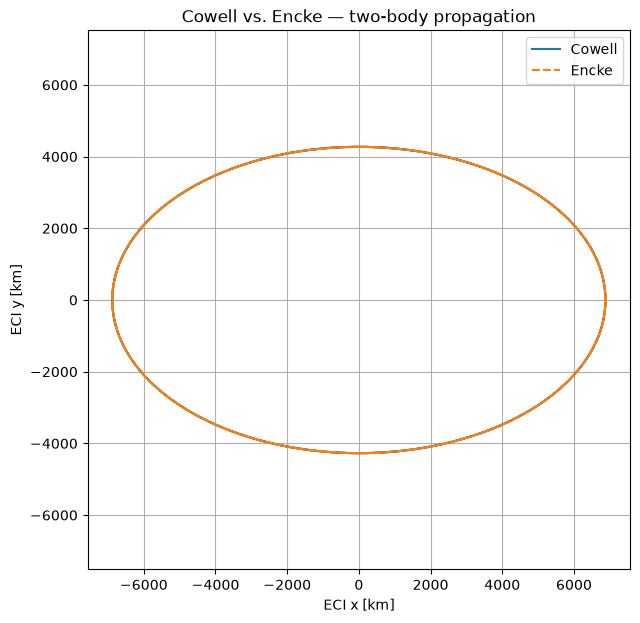

In [38]:
# Plot 1A: trajectory overlay
plt.figure(figsize=(7, 7))
plt.plot(X_cowell[0] / 1000, X_cowell[1] / 1000, label="Cowell")

if X_encke is not None:
    plt.plot(X_encke[0] / 1000, X_encke[1] / 1000, "--", label="Encke")

plt.xlabel("ECI x [km]")
plt.ylabel("ECI y [km]")
plt.title("Cowell vs. Encke — two-body propagation")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()


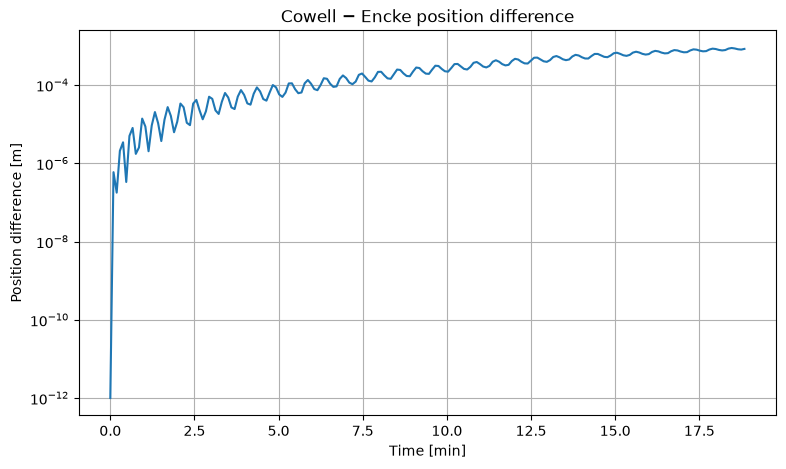

Maximum position difference: 1.961929e-02 m
Final position difference:   1.961929e-02 m


In [ ]:
# Plot 1B: Cowell-Encke position difference
if X_encke is not None:
    n_common = min(X_cowell.shape[1], X_encke.shape[1])
    err_r_m = position_error_m(
        X_cowell[:, :n_common],
        X_encke[:, :n_common],
    )
    t_common = np.linspace(0.0, duration, n_common)

    plt.figure(figsize=(9, 5))
    plt.semilogy(t_common / 60, np.maximum(err_r_m, 1e-12))
    plt.xlabel("Time [min]")
    plt.ylabel("Position difference [m]")
    plt.title("Cowell − Encke position difference")
    plt.grid()
    plt.show()

    print(f"Maximum position difference: {err_r_m.max():.6e} m")
    print(f"Final position difference:   {err_r_m[-1]:.6e} m")
else:
    print("Skipped because Encke propagation did not run successfully.")


# Test 2 — Effects of $J_2$ and drag

The propagator is held fixed as Cowell while the force model changes.


In [23]:
duration = 600 * 3600.0
N = 250

cases = {
    "None": dict(J2=False, drag=False),
    "J2": dict(J2=True, drag=False),
    "Drag": dict(J2=False, drag=True),
    "J2 + drag": dict(J2=True, drag=True),
}

solutions = {}

for name, opts in cases.items():
    t_force, X = run_case(
        x0,
        duration,
        method="cowell",
        n=N,
        **opts,
    )
    solutions[name] = X
    print(name, X.shape)


None (6, 250)
J2 (6, 250)
Drag (6, 250)
J2 + drag (6, 250)


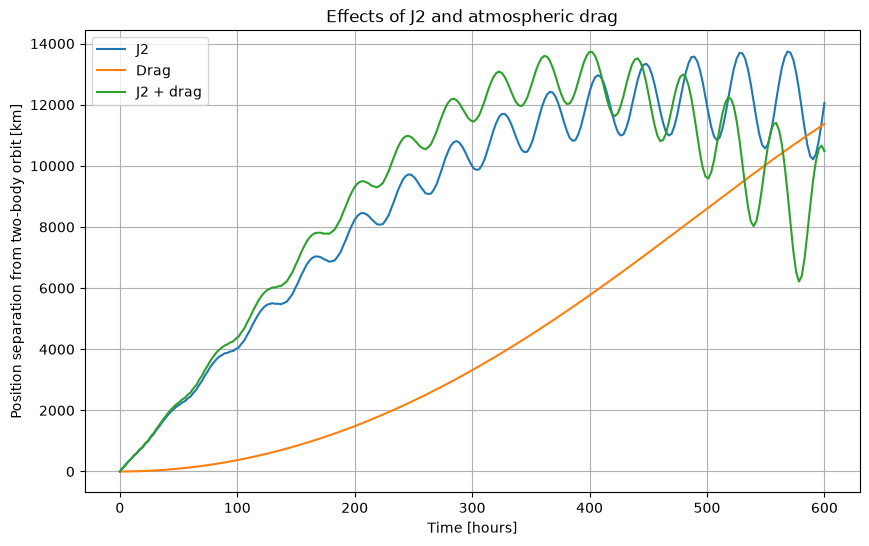

In [24]:
# Plot 2A: position separation from pure two-body propagation
X_base = solutions["None"]

plt.figure(figsize=(10, 6))

for name in ["J2", "Drag", "J2 + drag"]:
    dr_m = position_error_m(solutions[name], X_base)
    plt.plot(t_force / 3600, dr_m / 1000, label=name)

plt.xlabel("Time [hours]")
plt.ylabel("Position separation from two-body orbit [km]")
plt.title("Effects of J2 and atmospheric drag")
plt.grid()
plt.legend()
plt.show()


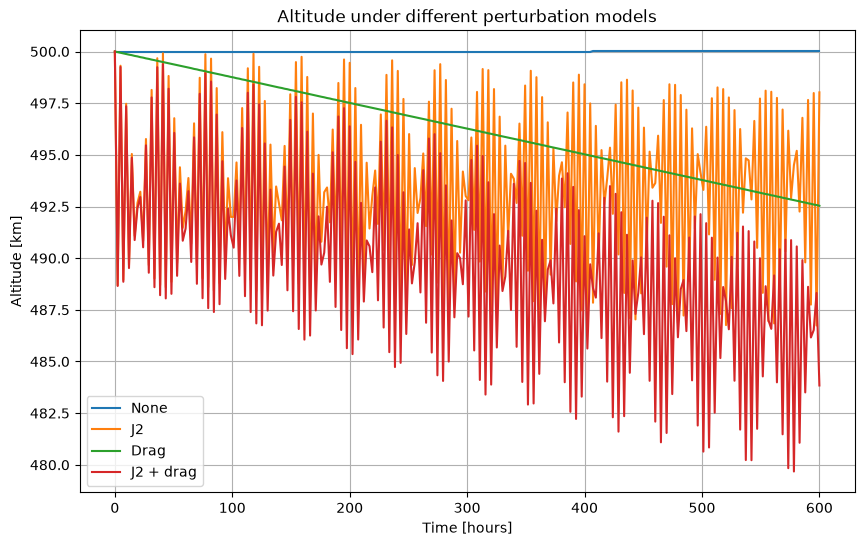

In [25]:
# Plot 2B: altitude comparison
plt.figure(figsize=(10, 6))

for name, X in solutions.items():
    plt.plot(t_force / 3600, altitude_m(X) / 1000, label=name)

plt.xlabel("Time [hours]")
plt.ylabel("Altitude [km]")
plt.title("Altitude under different perturbation models")
plt.grid()
plt.legend()
plt.show()


# Test 3 — Effect of propagation duration

Compare Cowell and Encke with the same force model over progressively longer intervals. This example uses $J_2$ on and drag off.


In [26]:
durations = {
    "10 min": 10 * 60.0,
    "1 orbit": T_orbit,
    "3 orbits": 3 * T_orbit,
    "6 hr": 6 * 3600.0,
    "24 hr": 24 * 3600.0,
}

duration_hours = []
final_errors_m = []
max_errors_m = []

for label, duration_s in durations.items():
    N = max(500, int(duration_s / 15) + 1)

    t_c, X_c = run_case(
        x0,
        duration_s,
        method="cowell",
        J2=True,
        drag=False,
        n=N,
    )

    t_e, X_e = run_case(
        x0,
        duration_s,
        method="encke",
        J2=True,
        drag=False,
        n=N,
    )

    if X_e is None:
        print(f"{label:10s} | skipped")
        continue

    n_common = min(X_c.shape[1], X_e.shape[1])
    dr_m = position_error_m(X_c[:, :n_common], X_e[:, :n_common])

    duration_hours.append(duration_s / 3600)
    final_errors_m.append(dr_m[-1])
    max_errors_m.append(dr_m.max())

    print(
        f"{label:10s} | "
        f"final error = {dr_m[-1]:.6e} m | "
        f"max error = {dr_m.max():.6e} m"
    )


10 min     | final error = 8.014106e-02 m | max error = 8.014106e-02 m
1 orbit    | final error = 1.520633e+03 m | max error = 1.520978e+03 m
3 orbits   | final error = 4.551887e+03 m | max error = 4.561165e+03 m
6 hr       | final error = 4.999801e+03 m | max error = 4.999801e+03 m
24 hr      | final error = 1.210416e+04 m | max error = 2.258050e+04 m


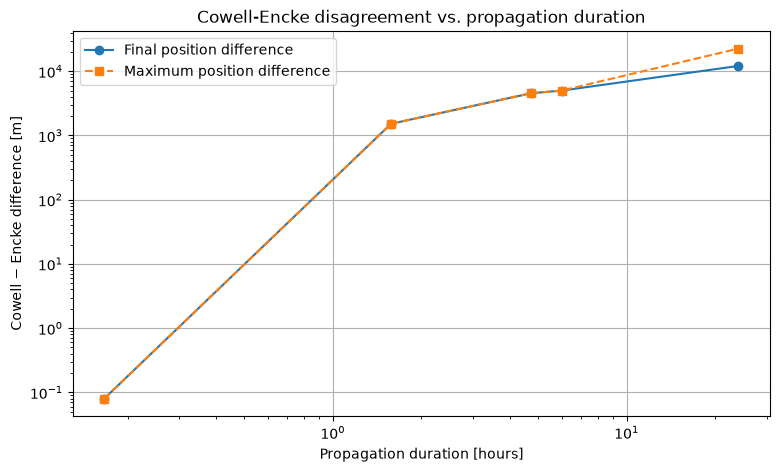

In [27]:
# Plot 3: disagreement vs. propagation duration
if duration_hours:
    plt.figure(figsize=(9, 5))

    plt.loglog(
        duration_hours,
        final_errors_m,
        "o-",
        label="Final position difference",
    )

    plt.loglog(
        duration_hours,
        max_errors_m,
        "s--",
        label="Maximum position difference",
    )

    plt.xlabel("Propagation duration [hours]")
    plt.ylabel("Cowell − Encke difference [m]")
    plt.title("Cowell-Encke disagreement vs. propagation duration")
    plt.grid()
    plt.legend()
    plt.show()
else:
    print("No Encke duration tests completed successfully.")


# Test 4 — Compare against CelesTrak + SGP4

This downloads a current TLE from CelesTrak and propagates it with SGP4.

A TLE is not a sequence of raw measured Cartesian states; it is an SGP4-specific mean-element representation fitted to tracking data. So this is a comparison against a standard operational orbit model.

SGP4 outputs TEME coordinates in km and km/s. The helper below converts TEME → GCRS and then converts the state to **m and m/s**.


In [ ]:
import requests
import astropy.units as u

from astropy.time import Time
from astropy.coordinates import (
    TEME,
    GCRS,
    CartesianRepresentation,
    CartesianDifferential,
)

from sgp4.api import Satrec
from sgp4.conveniences import sat_epoch_datetime

# CANX-2
CATNR = 32790

# url = (
#     "https://celestrak.org/NORAD/elements/gp.php"
#     f"?CATNR={CATNR}&FORMAT=TLE"
# )

# response = requests.get(url, timeout=20)
# response.raise_for_status()

# with open("CANX-2.tle", "w") as f:
#     f.write(response.text)

from sgp4.api import Satrec

with open("CANX-2.tle", "r") as f:
    lines = [
        line.strip()
        for line in f.readlines()
        if line.strip()
    ]

# CelesTrak usually gives:
# name
# line 1
# line 2

if lines[0].startswith("1 "):
    line1 = lines[0]
    line2 = lines[1]
else:
    satellite_name = lines[0]
    line1 = lines[1]
    line2 = lines[2]

sat = Satrec.twoline2rv(line1, line2)
tle_epoch = sat_epoch_datetime(sat)

print()
print("Satellite:", satellite_name)
print("TLE epoch:", tle_epoch)



Satellite: CANX-2
TLE epoch: 2026-08-18 22:49:23.095199+00:00


In [19]:
def teme_to_gcrs_m(r_teme_km, v_teme_km_s, dt):
    obstime = Time(dt)

    rep = CartesianRepresentation(
        np.asarray(r_teme_km, dtype=float) * u.km,
        differentials=CartesianDifferential(
            np.asarray(v_teme_km_s, dtype=float) * u.km / u.s
        ),
    )

    teme = TEME(rep, obstime=obstime)
    gcrs = teme.transform_to(GCRS(obstime=obstime))

    r_m = gcrs.cartesian.xyz.to_value(u.m)
    v_m_s = (
        gcrs.cartesian
        .differentials["s"]
        .d_xyz
        .to_value(u.m / u.s)
    )

    return np.concatenate([r_m, v_m_s])


def sgp4_state_gcrs_m(sat, dt):
    obstime = Time(dt)

    error, r_teme_km, v_teme_km_s = sat.sgp4(
        obstime.jd1,
        obstime.jd2,
    )

    if error != 0:
        raise RuntimeError(f"SGP4 error code {error} at {dt}")

    return teme_to_gcrs_m(r_teme_km, v_teme_km_s, dt)


In [26]:
# Build a 6-hour SGP4 reference trajectory starting at the TLE epoch.
duration_real = 600 * 3600.0
N_real = 1000

times_real_s = np.linspace(0.0, duration_real, N_real)

datetimes_real = [
    tle_epoch + timedelta(seconds=float(t))
    for t in times_real_s
]

X_sgp4 = np.column_stack([
    sgp4_state_gcrs_m(sat, dt)
    for dt in datetimes_real
])

x0_real = X_sgp4[:, 0]

print("Initial GCRS state from CelesTrak/SGP4 [m, m/s]:")
print(x0_real)
print("Reference trajectory shape:", X_sgp4.shape)


Initial GCRS state from CelesTrak/SGP4 [m, m/s]:
[-5.90513568e+06 -3.63927088e+06  1.54983772e+04 -5.17867809e+02
  8.87263297e+02  7.50860677e+03]
Reference trajectory shape: (6, 1000)


In [28]:
# Propagate the same initial state with your own models.
_, X_cowell_2body = run_case(
    x0_real,
    duration_real,
    method="cowell",
    J2=False,
    drag=False,
    n=N_real,
    t0=tle_epoch,
)

_, X_cowell_j2 = run_case(
    x0_real,
    duration_real,
    method="cowell",
    J2=True,
    drag=False,
    n=N_real,
    t0=tle_epoch,
)

_, X_cowell_full = run_case(
    x0_real,
    duration_real,
    method="cowell",
    J2=True,
    drag=True,
    n=N_real,
    t0=tle_epoch,
)

# _, X_encke_J2 = run_case(
#     x0_real,
#     duration_real,
#     method="encke",
#     J2=True,
#     drag=False,
#     n=N_real,
#     t0=tle_epoch,
# )

# _, X_encke_two_body = run_case(
#     x0_real,
#     duration_real,
#     method="encke",
#     J2=False,
#     drag=False,
#     n=N_real,
#     t0=tle_epoch,
# )


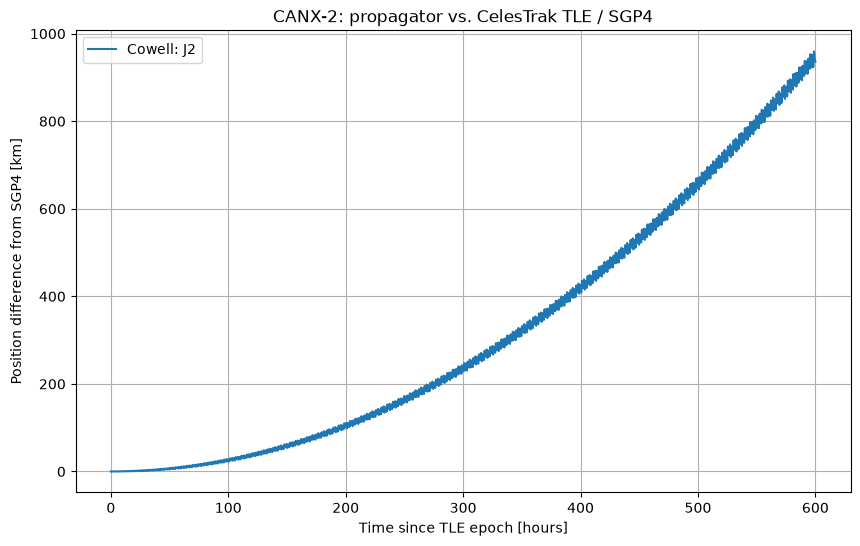

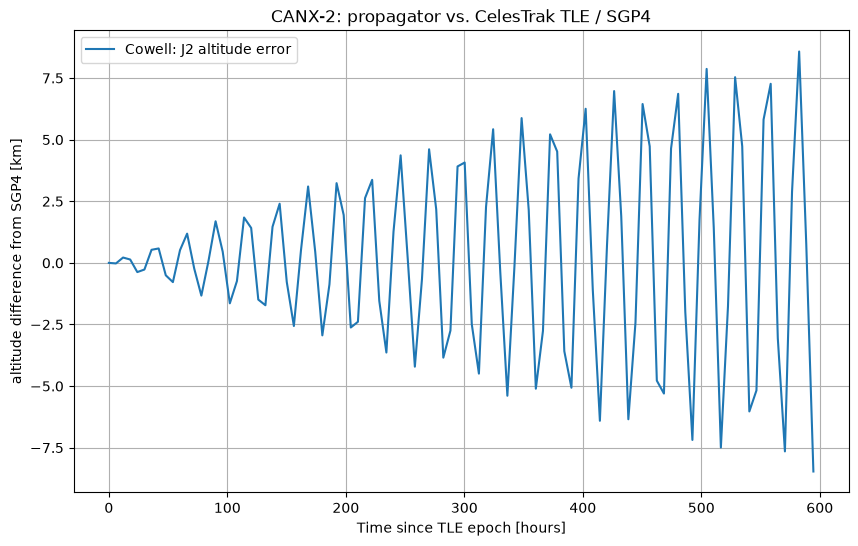

In [33]:
# Plot 4: position error relative to CelesTrak TLE + SGP4
err_2body_m = position_error_m(X_cowell_2body, X_sgp4)
err_j2_m = position_error_m(X_cowell_j2, X_sgp4)
err_full_m = position_error_m(X_cowell_full, X_sgp4)
err_att_m = altitude_m(X_cowell_j2)-altitude_m(X_sgp4)

plt.figure(figsize=(10, 6))

# plt.plot(times_real_s / 3600, err_2body_m / 1000, label="Cowell: two-body")
plt.plot(times_real_s / 3600, err_j2_m / 1000, label="Cowell: J2")
# plt.plot(times_real_s / 3600, err_full_m / 1000, label="Cowell: J2 + drag")

# if X_encke_J2 is not None:
#     n_common = min(X_encke_J2.shape[1], X_sgp4.shape[1])
#     err_encke_m = position_error_m(
#         X_encke_J2[:, :n_common],
#         X_sgp4[:, :n_common],
#     )
#     t_encke_real = np.linspace(0.0, duration_real, n_common)
#     plt.plot(
#         t_encke_real / 3600,
#         err_encke_m / 1000,
#         label="Encke: J2",
#     )

plt.xlabel("Time since TLE epoch [hours]")
plt.ylabel("Position difference from SGP4 [km]")
plt.title(f"{satellite_name}: propagator vs. CelesTrak TLE / SGP4")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(times_real_s[::10] / 3600, err_att_m[::10] / 1000, label="Cowell: J2 altitude error")

plt.xlabel("Time since TLE epoch [hours]")
plt.ylabel("altitude difference from SGP4 [km]")
plt.title(f"{satellite_name}: propagator vs. CelesTrak TLE / SGP4")
plt.grid()
plt.legend()
plt.show()


In [49]:
# Summary statistics
comparison_models = {
    "Cowell two-body": X_cowell_2body,
    "Cowell J2": X_cowell_j2,
    "Cowell J2 + drag": X_cowell_full,
}

if X_encke_J2 is not None:
    comparison_models["Encke J2 + drag"] = X_encke_J2

print("Comparison against SGP4")
print("-" * 75)

for name, X in comparison_models.items():
    n_common = min(X.shape[1], X_sgp4.shape[1])
    err_m = position_error_m(
        X[:, :n_common],
        X_sgp4[:, :n_common],
    )

    print(
        f"{name:22s} "
        f"final = {err_m[-1] / 1000:12.6f} km | "
        f"RMS = {rms(err_m) / 1000:12.6f} km | "
        f"max = {err_m.max() / 1000:12.6f} km"
    )


Comparison against SGP4
---------------------------------------------------------------------------
Cowell two-body        final =   274.774655 km | RMS =   154.689787 km | max =   274.774655 km
Cowell J2              final =     1.424414 km | RMS =     0.805784 km | max =     1.503746 km
Cowell J2 + drag       final =     2.766116 km | RMS =     1.384004 km | max =     2.774483 km
Encke J2 + drag        final =     4.389918 km | RMS =     1.730346 km | max =     4.389918 km
